### Enhanced by Claude for readability

# EO Soil Carbon Prediction Pipeline

**Goal**: Predict coastal wetland soil organic carbon from satellite data using
3-5 domain-driven spectral features instead of PCA-reduced 500+ features.

**Primary metric**: Leave-One-Study-Out (LOSO) R² — the most honest
measure of generalization to unseen study sites.

## Section A — Setup and Configuration

In [33]:
# ── Imports ──────────────────────────────────────────────────────────────────
from __future__ import annotations

import warnings, json, joblib, time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter

# ML
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import (
    LeaveOneOut,
    LeaveOneGroupOut,
    GroupKFold,
    KFold,
    cross_val_predict,
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

# Earth Engine (optional)
try:
    import ee
    import geemap
    _EE_IMPORTED = True
except ImportError:
    _EE_IMPORTED = False

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style("whitegrid")
print("All imports OK.")


All imports OK.


In [34]:
# ── Constants ────────────────────────────────────────────────────────────────
DATA_DIR   = Path("../../../data/CCN_synthesis")
OUT_DIR    = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)

# Depth targets (cm) — separate model trained per depth
DEPTH_TARGETS = [0, 30, 100]

# Study region: CONUS coastal (matches local_emit_extract REGION).
# Covers Gulf, mid-Atlantic, Chesapeake, Florida Everglades, Pacific NW marshes.
REGION_BBOX = dict(lat_min=24.0, lat_max=49.0, lon_min=-125.0, lon_max=-65.0)

# Modelling
MIN_SAMPLES   = 15        # lowered from v1's 20 to include more depths
RANDOM_STATE  = 42

# Optional modules
USE_OSSL = False           # set True if you have OSSL data in data/ossl/
EE_PROJECT = "ee-klewtak"  # your Earth Engine project

print(f"Data dir exists: {DATA_DIR.exists()}")
print(f"Region: {REGION_BBOX}")


Data dir exists: True
Region: {'lat_min': 24.0, 'lat_max': 49.0, 'lon_min': -125.0, 'lon_max': -65.0}


In [35]:
# ── Earth Engine authentication (graceful fallback) ──────────────────────────
EE_AVAILABLE = False

if _EE_IMPORTED:
    try:
        ee.Initialize(project="nasa-eo-ccn")
        EE_AVAILABLE = True
        print("Earth Engine initialised (already authenticated).")
    except Exception:
        try:
            ee.Authenticate(auth_mode="notebook", force=True)
            ee.Initialize(project="nasa-eo-ccn")
            EE_AVAILABLE = True
            print("Earth Engine authenticated and initialised.")
        except Exception as exc:
            print(f"Earth Engine unavailable: {exc}")
            print("Continuing with cached data only.")
else:
    print("earthengine-api not installed — using cached data only.")

print(f"EE_AVAILABLE = {EE_AVAILABLE}")

Earth Engine initialised (already authenticated).
EE_AVAILABLE = True


In [36]:
# ── Load CCN synthesis data ──────────────────────────────────────────────────
cores = pd.read_csv(DATA_DIR / "CCN_cores.csv", low_memory=False)
depthseries = pd.read_csv(DATA_DIR / "CCN_depthseries.csv", low_memory=False)

print(f"Cores: {cores.shape}  |  Depthseries: {depthseries.shape}")

# Filter to study region
core_locs = cores[
    ["study_id", "site_id", "core_id", "latitude", "longitude", "habitat"]
].dropna(subset=["latitude", "longitude"])
core_locs = core_locs[
    (core_locs["latitude"]  >= REGION_BBOX["lat_min"])
    & (core_locs["latitude"]  <= REGION_BBOX["lat_max"])
    & (core_locs["longitude"] >= REGION_BBOX["lon_min"])
    & (core_locs["longitude"] <= REGION_BBOX["lon_max"])
]
print(f"Cores in study region: {len(core_locs):,}")


def extract_carbon_at_depth(depthseries: pd.DataFrame, depth_target: int) -> pd.DataFrame:
    """Extract mean fraction_carbon for cores whose depth range spans *depth_target*.
    
    Preserves study_id and site_id for spatial cross-validation.
    """
    layer = depthseries[
        (depthseries["depth_min"] <= depth_target)
        & (depthseries["depth_max"] > depth_target)
    ].copy()
    layer = layer[layer["fraction_carbon"].notna()]

    agg = (
        layer.groupby(["study_id", "site_id", "core_id"])
        .agg(fraction_carbon=("fraction_carbon", "mean"))
        .reset_index()
    )
    merged = agg.merge(core_locs, on=["study_id", "site_id", "core_id"])
    merged = merged.dropna(subset=["latitude", "longitude"])
    merged = merged[(merged["fraction_carbon"] > 0) & (merged["fraction_carbon"] <= 1.0)]
    return merged


depth_datasets = {}
for d in DEPTH_TARGETS:
    df = extract_carbon_at_depth(depthseries, d)
    depth_datasets[d] = df
    studies = df["study_id"].nunique()
    sites   = df["site_id"].nunique()
    print(f"  Depth {d:>3d} cm: {len(df):>4d} cores, {studies} studies, {sites} sites, "
          f"carbon [{df['fraction_carbon'].min():.3f} – {df['fraction_carbon'].max():.3f}]")

Cores: (16715, 39)  |  Depthseries: (117518, 49)
Cores in study region: 6,411
  Depth   0 cm: 1200 cores, 74 studies, 413 sites, carbon [0.001 – 0.510]
  Depth  30 cm:  519 cores, 55 studies, 282 sites, carbon [0.001 – 0.499]
  Depth 100 cm:  111 cores, 17 studies, 60 sites, carbon [0.003 – 0.348]


## Section B — Spectral Data Loading

Load EMIT L2A hyperspectral reflectance. Uses a cached CSV if available,
otherwise extracts from Google Earth Engine.

In [37]:
# ── Load EMIT spectra from local_emit_extract outputs ─────────────────────────
# local_emit_extract.ipynb writes two CSVs to outputs/local_emit_extract/:
#   • emit_spectra_wide.csv  — one row per site; reflectance_0..N + metadata
#   • emit_spectra_long.csv  — tidy (site × band) with true wavelength_nm
#                              from EMIT image metadata
EMIT_DIR      = OUT_DIR / "local_emit_extract"
EMIT_WIDE_CSV = EMIT_DIR / "emit_spectra_wide.csv"
EMIT_LONG_CSV = EMIT_DIR / "emit_spectra_long.csv"

if not EMIT_WIDE_CSV.exists():
    raise FileNotFoundError(
        f"No EMIT extract found at {EMIT_WIDE_CSV}.\n"
        "Run EO/local_emit_extract.ipynb first."
    )

spectra_df = pd.read_csv(EMIT_WIDE_CSV)
print(f"Loaded EMIT wide CSV: {spectra_df.shape}  from {EMIT_WIDE_CSV}")

# Pull the true per-band wavelengths from the long CSV.
wavelength_map: dict | None = None
if EMIT_LONG_CSV.exists():
    _long = pd.read_csv(EMIT_LONG_CSV, usecols=["band", "wavelength_nm"])
    _long = _long.drop_duplicates("band")
    wavelength_map = dict(zip(_long["band"], _long["wavelength_nm"]))
    print(f"Loaded wavelength map: {len(wavelength_map)} bands, "
          f"{min(wavelength_map.values()):.1f}-{max(wavelength_map.values()):.1f} nm")
else:
    print("WARN: emit_spectra_long.csv missing - will fall back to linspace wavelengths.")

# ── Quality filter: drop rows with any cloud/water flag set ─────────────────
quality_flags = [c for c in ("cloud_flag", "dilated_cloud_flag", "water_flag",
                             "cirrus_flag") if c in spectra_df.columns]
if quality_flags:
    pre_n = len(spectra_df)
    spectra_df = spectra_df.loc[(spectra_df[quality_flags] == 0).all(axis=1)].copy()
    print(f"Quality filter on {quality_flags}: kept {len(spectra_df)}/{pre_n} rows")

# ── Normalise EMIT extract schema to canonical CCN ──────────────────────────
# local_emit_extract previously wrote site_id as a composite "study__site"
# string with the original CCN site_id stored under `name`. Detect and unwind.
if "name" in spectra_df.columns and "site_id" in spectra_df.columns:
    sample_sid  = str(spectra_df["site_id"].dropna().iloc[0])
    sample_name = str(spectra_df["name"].dropna().iloc[0])
    if "__" in sample_sid and sample_name and sample_name in sample_sid:
        print("Normalising EMIT schema: site_id ← name (preserving composite as _emit_site_id)")
        spectra_df = spectra_df.rename(columns={
            "site_id": "_emit_site_id",
            "name":    "site_id",
        })

# Drop the per-site core_id (one arbitrary core per site from the extract).
# Real per-core core_id comes from the CCN_depthseries merge in cell 14.
if "core_id" in spectra_df.columns:
    spectra_df = spectra_df.rename(columns={"core_id": "_emit_core_id"})

print(f"\nFinal spectra_df: {spectra_df.shape}")
print(f"ID columns: {[c for c in ('study_id','site_id') if c in spectra_df.columns]}")
print(f"Sample IDs: study_id={spectra_df['study_id'].iloc[0]!r}, "
      f"site_id={spectra_df['site_id'].iloc[0]!r}")


Loaded EMIT wide CSV: (1379, 586)  from outputs\local_emit_extract\emit_spectra_wide.csv
Loaded wavelength map: 285 bands, 381.0-2493.0 nm
Quality filter on ['cloud_flag', 'dilated_cloud_flag', 'water_flag', 'cirrus_flag']: kept 1103/1379 rows
Normalising EMIT schema: site_id ← name (preserving composite as _emit_site_id)

Final spectra_df: (1103, 586)
ID columns: ['study_id', 'site_id']
Sample IDs: study_id='Abbott_et_al_2019', site_id='1983'


In [38]:
# ── Band filtering ───────────────────────────────────────────────────────────
# Identify numbered reflectance columns (excluding reflectance_uncertainty_*)
import re as _re
_refl_pat = _re.compile(r"^reflectance_(\d+)$")
refl_cols = sorted(
    [c for c in spectra_df.columns if _refl_pat.match(c)],
    key=lambda x: int(_refl_pat.match(x).group(1)),
)
n_bands = len(refl_cols)

# Prefer the true wavelength map from emit_spectra_long.csv; fall back to
# a uniform grid covering EMIT's full 381-2493 nm range if the long file
# wasn't loaded.
if wavelength_map is not None and all(c in wavelength_map for c in refl_cols):
    wavelengths = np.array([wavelength_map[c] for c in refl_cols], dtype=float)
    print(f"Using per-band wavelengths from emit_spectra_long.csv")
else:
    wavelengths = np.linspace(381, 2493, n_bands)
    print(f"Using linspace wavelengths 381-2493 nm (no ground-truth map).")

wl_min, wl_max = float(wavelengths.min()), float(wavelengths.max())
print(f"Available wavelengths: {wl_min:.1f} - {wl_max:.1f} nm  ({n_bands} bands)")

# Remove water-vapour absorption windows (1350-1450 nm, 1800-1950 nm)
keep_mask = ~(
    ((wavelengths >= 1350) & (wavelengths <= 1450))
    | ((wavelengths >= 1800) & (wavelengths <= 1950))
)
keep_cols = [refl_cols[i] for i in range(n_bands) if keep_mask[i]]
wavelengths_kept = wavelengths[keep_mask]

print(f"Total bands: {n_bands}  |  Kept: {len(keep_cols)}  |  Removed: "
      f"{n_bands - len(keep_cols)}")
print(f"Kept wavelength range: {wavelengths_kept[0]:.0f} - "
      f"{wavelengths_kept[-1]:.0f} nm")

# Report which planned domain features are reachable given the available range
_feature_centers = {"NDVI-Red": 660, "NDVI-NIR": 858, "Lignin": 1730,
                    "Cellulose": 2100, "OC (2300)": 2300, "SWIR-mean": 2200}
_unreachable = [n for n, wl in _feature_centers.items()
                if wl < wl_min or wl > wl_max]
if _unreachable:
    print(f"WARN: Extract does not cover SWIR wavelengths needed by: "
          f"{_unreachable}. Those features will be NaN and dropped "
          f"automatically downstream. Re-run local_emit_extract with the full "
          f"EMIT band set to get them.")


Using per-band wavelengths from emit_spectra_long.csv
Available wavelengths: 381.0 - 2493.0 nm  (285 bands)
Total bands: 285  |  Kept: 252  |  Removed: 33
Kept wavelength range: 381 - 2493 nm


Spectra valid for plotting: 1103/1103


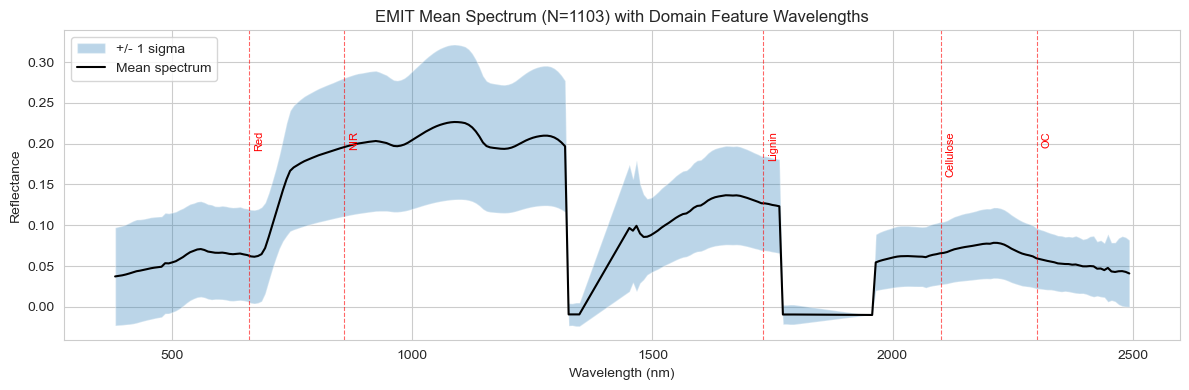

In [39]:
# ── Spectral diagnostic plot ─────────────────────────────────────────────────
X_all_raw = spectra_df[keep_cols].values.astype(np.float64)
valid_rows = np.isfinite(X_all_raw).all(axis=1)
X_plot = X_all_raw[valid_rows]
print(f"Spectra valid for plotting: {valid_rows.sum()}/{len(valid_rows)}")

fig, ax = plt.subplots(figsize=(12, 4))
if len(X_plot) > 0:
    mean_spec = np.nanmean(X_plot, axis=0)
    std_spec  = np.nanstd(X_plot, axis=0)
    ax.fill_between(wavelengths_kept, mean_spec - std_spec, mean_spec + std_spec,
                    alpha=0.3, label="+/- 1 sigma")
    ax.plot(wavelengths_kept, mean_spec, "k-", lw=1.5, label="Mean spectrum")
    y_anchor = float(np.nanmax(mean_spec)) * 0.95
else:
    y_anchor = 1.0

# Mark the 5 domain feature wavelengths; grey out any outside the available range
wl_min, wl_max = float(wavelengths_kept.min()), float(wavelengths_kept.max())
for wl, name in [(660, "Red"), (858, "NIR"), (1730, "Lignin"),
                 (2100, "Cellulose"), (2300, "OC")]:
    in_range = wl_min <= wl <= wl_max
    color = "red" if in_range else "#aaaaaa"
    style = "--" if in_range else ":"
    ax.axvline(wl, color=color, ls=style, alpha=0.6, lw=0.8)
    label = name if in_range else f"{name} (out of range)"
    ax.text(wl + 10, y_anchor, label, fontsize=8, color=color,
            rotation=90, va="top")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.set_title(f"EMIT Mean Spectrum (N={len(X_plot)}) with Domain Feature Wavelengths")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## Section C — Domain-Driven Feature Engineering (PRIMARY)

Replace PCA-30 with **5 interpretable spectral features** chosen from soil
spectroscopy literature:

| Feature | Wavelength | Physical basis |
|---------|-----------|----------------|
| `abs_oc_2300` | 2300 nm | C-H stretch combination — strongest SOC indicator |
| `abs_lignin_1730` | 1730 nm | C=O stretch of lignin / humic substances |
| `abs_cellulose_2100` | 2100 nm | O-H / C-O combination (plant-derived carbohydrates) |
| `ndvi` | 858/660 nm | Vegetation density proxy (litter input, root carbon) |
| `swir_mean` | 2000-2400 nm | Mean SWIR reflectance (inversely related to organic matter) |

In [40]:
# ── Absorption depth function ────────────────────────────────────────────────

def _nearest_idx(wavelengths: np.ndarray, target_nm: float) -> int:
    """Index of the wavelength closest to *target_nm*."""
    return int(np.argmin(np.abs(wavelengths - target_nm)))


def absorption_depth(
    spectra: np.ndarray,
    wavelengths: np.ndarray,
    center_nm: float,
    shoulder_left_nm: float,
    shoulder_right_nm: float,
) -> np.ndarray:
    """Continuum-removed absorption depth at *center_nm*.

    depth = 1 - R(center) / R_continuum(center)
    where R_continuum is linearly interpolated between the two shoulders.

    Parameters
    ----------
    spectra : (N, B) reflectance array
    wavelengths : (B,) wavelength vector in nm
    center_nm, shoulder_left_nm, shoulder_right_nm : absorption geometry

    Returns
    -------
    (N,) absorption depth values (higher = stronger absorption)
    """
    ic = _nearest_idx(wavelengths, center_nm)
    il = _nearest_idx(wavelengths, shoulder_left_nm)
    ir = _nearest_idx(wavelengths, shoulder_right_nm)

    R_center = spectra[:, ic]
    R_left   = spectra[:, il]
    R_right  = spectra[:, ir]

    # Linear continuum between shoulders, evaluated at center wavelength
    wl_c = wavelengths[ic]
    wl_l = wavelengths[il]
    wl_r = wavelengths[ir]
    frac = (wl_c - wl_l) / max(wl_r - wl_l, 1e-8)
    R_continuum = R_left + frac * (R_right - R_left)

    # Guard against zero / negative continuum
    R_continuum = np.where(R_continuum > 0, R_continuum, 1e-8)
    return 1.0 - R_center / R_continuum


print("absorption_depth() defined.")

absorption_depth() defined.


In [41]:
# ── Compute the 5 domain features ────────────────────────────────────────────

DOMAIN_FEATURES = [
    # (name, type, kwargs)
    ("abs_oc_2300",       "absorption", dict(center_nm=2300, shoulder_left_nm=2230, shoulder_right_nm=2380)),
    ("abs_lignin_1730",   "absorption", dict(center_nm=1730, shoulder_left_nm=1680, shoulder_right_nm=1780)),
    ("abs_cellulose_2100","absorption", dict(center_nm=2100, shoulder_left_nm=2000, shoulder_right_nm=2200)),
    ("ndvi",              "index",      None),
    ("swir_mean",         "index",      None),
]


def _wl_in_range(wavelengths: np.ndarray, target_nm: float, tol_nm: float = 30.0) -> bool:
    """True if *target_nm* is within the available wavelength range (w/ tolerance)."""
    return (wavelengths.min() - tol_nm) <= target_nm <= (wavelengths.max() + tol_nm)


def compute_domain_features(
    X_raw: np.ndarray,
    wavelengths: np.ndarray,
) -> tuple[np.ndarray, list[str]]:
    """Compute up-to-5 domain-driven features for soil carbon prediction.

    Features whose target wavelengths are outside the available range are
    *skipped* rather than returned as NaN — this keeps StandardScaler and the
    downstream models NaN-free. The returned feature_names list reflects what
    was actually computed.
    """
    n_samples, n_bands = X_raw.shape
    wl_min, wl_max = float(wavelengths.min()), float(wavelengths.max())

    # Smooth spectra to reduce per-band noise
    window = min(11, n_bands if n_bands % 2 == 1 else n_bands - 1)
    X_smooth = savgol_filter(X_raw, window_length=window, polyorder=2, axis=1)

    features: dict[str, np.ndarray] = {}
    skipped: list[tuple[str, str]] = []

    # 1-3: Absorption depths at key organic-matter wavelengths
    for name, ftype, kwargs in DOMAIN_FEATURES:
        if ftype != "absorption":
            continue
        required = [kwargs["center_nm"], kwargs["shoulder_left_nm"],
                    kwargs["shoulder_right_nm"]]
        if all(_wl_in_range(wavelengths, wl) for wl in required):
            features[name] = absorption_depth(X_smooth, wavelengths, **kwargs)
        else:
            skipped.append((name, f"requires {required} nm, have {wl_min:.0f}-{wl_max:.0f} nm"))

    # 4: NDVI (needs 660 + 858 nm)
    if _wl_in_range(wavelengths, 660) and _wl_in_range(wavelengths, 858):
        nir = X_smooth[:, _nearest_idx(wavelengths, 858)]
        red = X_smooth[:, _nearest_idx(wavelengths, 660)]
        features["ndvi"] = (nir - red) / np.where((nir + red) > 0, nir + red, 1e-8)
    else:
        skipped.append(("ndvi", f"requires 660+858 nm, have {wl_min:.0f}-{wl_max:.0f} nm"))

    # 5: Mean SWIR reflectance (2000-2400 nm). Skip entirely if no bands fall in
    # the window — silences the "Mean of empty slice" numpy warning.
    swir_mask = (wavelengths >= 2000) & (wavelengths <= 2400)
    if swir_mask.any():
        features["swir_mean"] = X_smooth[:, swir_mask].mean(axis=1)
    else:
        skipped.append(("swir_mean", f"needs any band in 2000-2400 nm, have {wl_min:.0f}-{wl_max:.0f} nm"))

    if skipped:
        print("Skipping features out of wavelength range:")
        for name, why in skipped:
            print(f"  - {name}: {why}")

    feature_names = list(features.keys())
    if not feature_names:
        raise ValueError(
            "No domain features could be computed — the wavelength range "
            f"({wl_min:.0f}-{wl_max:.0f} nm) does not cover any target feature. "
            "Re-run local_emit_extract.ipynb to get the full EMIT 381-2493 nm range."
        )
    X_domain = np.column_stack([features[n] for n in feature_names])
    return X_domain, feature_names


print("compute_domain_features() defined.")


compute_domain_features() defined.


In [ ]:
# ── Feature selection framework (RFECV with on-disk cache) ──────────────────
# RFECV (Recursive Feature Elimination with Cross-Validation) finds the
# optimal feature subset by repeatedly fitting the model, dropping the least
# important feature, and using CV to score each subset size. Far faster than
# forward selection at this dataset size, and answers the right question:
# "what subset of features maximises CV R²?"
#
# Results are cached to outputs/selected_features.json so subsequent notebook
# runs skip the (~5 min) selection step entirely. Set force_recompute=True
# to invalidate the cache.
import json as _json
from sklearn.feature_selection import RFECV

FEATURE_SELECTION_CACHE = OUT_DIR / "selected_features.json"


def select_features_rfecv(
    X: np.ndarray,
    y: np.ndarray,
    feature_names: list[str],
    min_k: int = 3,
    max_k: int | None = 10,
    cv: int = 5,
    n_estimators: int = 200,
    cache_path: Path | None = None,
    force_recompute: bool = False,
) -> tuple[list[str], dict]:
    """Select an R²-maximising feature subset via RFECV, with disk caching.

    Returns
    -------
    selected_names : list[str]
        The chosen feature names, in original column order.
    info : dict
        {selected, all_features, optimal_k, r2_per_k, r2_std_per_k}
    """
    cache_path = Path(cache_path) if cache_path else None

    # ── Try cache ───────────────────────────────────────────────────────────
    if cache_path and cache_path.exists() and not force_recompute:
        with open(cache_path) as f:
            cached = _json.load(f)
        if set(cached.get("all_features", [])) == set(feature_names):
            print(f"  ✓ Loaded cached selection from {cache_path.name}")
            print(f"    {len(cached['selected'])} features: {cached['selected']}")
            return cached["selected"], cached
        else:
            print(f"  ⚠ Cache feature pool changed — re-running selection.")

    # ── Run RFECV ───────────────────────────────────────────────────────────
    print(f"  Running RFECV on {X.shape[1]} candidate features "
          f"(cv={cv}, n_est={n_estimators})...")
    estimator = GradientBoostingRegressor(
        n_estimators=n_estimators, max_depth=3, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=3, random_state=RANDOM_STATE,
    )
    rfecv = RFECV(
        estimator=estimator, step=1, cv=cv, scoring="r2",
        min_features_to_select=min_k, n_jobs=-1,
    )
    rfecv.fit(X, y)

    selected_idx = list(np.where(rfecv.support_)[0])
    selected_names = [feature_names[i] for i in selected_idx]

    # If RFECV picked more than max_k, trim to top-max_k by importance
    if max_k is not None and len(selected_names) > max_k:
        rf_full = GradientBoostingRegressor(
            n_estimators=n_estimators, max_depth=3, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=3, random_state=RANDOM_STATE,
        ).fit(X[:, selected_idx], y)
        importances = rf_full.feature_importances_
        top_local = np.argsort(importances)[-max_k:]
        selected_idx = [selected_idx[i] for i in sorted(top_local)]
        selected_names = [feature_names[i] for i in selected_idx]
        print(f"  Capped to max_k={max_k}: {selected_names}")

    info = {
        "selected": selected_names,
        "all_features": feature_names,
        "optimal_k": int(rfecv.n_features_),
        "r2_per_k": rfecv.cv_results_["mean_test_score"].tolist(),
        "r2_std_per_k": rfecv.cv_results_["std_test_score"].tolist(),
    }

    if cache_path:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        with open(cache_path, "w") as f:
            _json.dump(info, f, indent=2)
        print(f"  ✓ Cached selection to {cache_path}")

    return selected_names, info


print(f"Feature-selection framework ready. Cache file: {FEATURE_SELECTION_CACHE}")


In [43]:
# ── Compute X_domain and X_habitat at surface depth (0 cm) ───────────────────
# This cell only computes features. Feature SELECTION happens in cell 31 once
# all candidate features (enviro + multisensor + habitat) are available.
TARGET_DEPTH = 0  # primary analysis depth
carbon_df = depth_datasets[TARGET_DEPTH]

# Merge on (study_id, site_id) — see cell 7 docstring.
merged = spectra_df.merge(
    carbon_df[["study_id", "site_id", "core_id", "fraction_carbon"]],
    on=["study_id", "site_id"],
    how="inner",
)
print(f"Merge: {len(spectra_df)} sites × {len(carbon_df)} carbon rows -> {len(merged)} rows")

X_raw  = merged[keep_cols].values.astype(np.float64)
y      = merged["fraction_carbon"].values
groups = merged["study_id"].values
sites  = merged["site_id"].values

valid = np.isfinite(X_raw).all(axis=1) & np.isfinite(y)
X_raw, y, groups, sites = X_raw[valid], y[valid], groups[valid], sites[valid]
merged_valid = merged.loc[valid].reset_index(drop=True)

print(f"Samples: {len(y)}  |  Studies: {len(np.unique(groups))}  "
      f"|  Sites: {len(np.unique(sites))}")
print(f"Carbon range: [{y.min():.3f}, {y.max():.3f}]  |  Mean: {y.mean():.3f}")

# ── Domain features ──────────────────────────────────────────────────────────
X_domain, feat_names = compute_domain_features(X_raw, wavelengths_kept)
print(f"\nDomain features ({len(feat_names)}): {feat_names}")
print(f"Feature matrix shape: {X_domain.shape}")

# Drop degenerate columns and impute residual NaN
col_nan_mask = np.isnan(X_domain).all(axis=0)
col_var      = np.nanvar(X_domain, axis=0)
bad_mask     = col_nan_mask | (col_var < 1e-12)
if bad_mask.any():
    dropped = [feat_names[i] for i in range(len(feat_names)) if bad_mask[i]]
    print(f"Dropping degenerate columns: {dropped}")
    keep = ~bad_mask
    X_domain   = X_domain[:, keep]
    feat_names = [n for n, k in zip(feat_names, keep) if k]
if np.isnan(X_domain).any():
    col_med = np.nanmedian(X_domain, axis=0)
    inds = np.where(np.isnan(X_domain))
    X_domain[inds] = np.take(col_med, inds[1])
    print(f"Imputed {len(inds[0])} NaN cells with column medians")

# ── Habitat one-hot ──────────────────────────────────────────────────────────
X_habitat = None
habitat_names: list[str] = []
if "habitat" in merged_valid.columns and merged_valid["habitat"].notna().any():
    hab_oh = pd.get_dummies(
        merged_valid["habitat"].fillna("unknown"), prefix="habitat"
    ).astype(float)
    keep_h = [c for c in hab_oh.columns if hab_oh[c].sum() >= 5]
    if keep_h:
        hab_oh = hab_oh[keep_h]
        X_habitat = hab_oh.values
        habitat_names = list(hab_oh.columns)
        print(f"Habitat one-hot ({len(habitat_names)}): {habitat_names}")
        print(f"  Counts: {hab_oh.sum().astype(int).to_dict()}")

print("\n→ Feature SELECTION will run in cell 31 once enviro + multisensor are computed.")


Merge: 1103 sites × 1200 carbon rows -> 897 rows
Samples: 897  |  Studies: 59  |  Sites: 298
Carbon range: [0.001, 0.510]  |  Mean: 0.159

Domain features (5): ['abs_oc_2300', 'abs_lignin_1730', 'abs_cellulose_2100', 'ndvi', 'swir_mean']
Feature matrix shape: (897, 5)
Habitat one-hot (5): ['habitat_mangrove', 'habitat_marsh', 'habitat_scrub/shrub', 'habitat_seagrass', 'habitat_swamp']
  Counts: {'habitat_mangrove': 88, 'habitat_marsh': 702, 'habitat_scrub/shrub': 19, 'habitat_seagrass': 14, 'habitat_swamp': 66}

→ Feature SELECTION will run in cell 31 once enviro + multisensor are computed.


## Section D — Environmental Covariates via Earth Engine

Add non-spectral features that literature shows improve SOC prediction:
- **Elevation & slope** from SRTM (topographic wetness, drainage)
- **Mean annual temperature & precipitation** from WorldClim (decomposition rates)
- **Distance to coast** (tidal influence, salinity)

All functions cache results to CSV and gracefully skip if EE is unavailable.

In [ ]:
# ── SRTM elevation & slope ───────────────────────────────────────────────────

def _nn_join_features(
    df: pd.DataFrame, lats: np.ndarray, lons: np.ndarray, cols: list[str],
) -> np.ndarray:
    """Nearest-neighbour join: for each (lat, lon), copy *cols* from the
    closest row in *df*. Robust to row-count mismatches between cached CSVs
    and the current sample set."""
    out = np.full((len(lats), len(cols)), np.nan)
    df_lat = df["latitude"].values
    df_lon = df["longitude"].values
    df_vals = df[cols].values
    for i, (la, lo) in enumerate(zip(lats, lons)):
        d2 = (df_lat - la) ** 2 + (df_lon - lo) ** 2
        out[i] = df_vals[int(np.argmin(d2))]
    for c in range(out.shape[1]):
        m = ~np.isfinite(out[:, c])
        if m.any():
            med = np.nanmedian(out[:, c])
            out[m, c] = med if np.isfinite(med) else 0.0
    return out


def extract_srtm_features(
    lats: np.ndarray,
    lons: np.ndarray,
    cache_file: Path = OUT_DIR / "srtm_features.csv",
) -> pd.DataFrame | None:
    """Extract elevation (m) and slope (degrees) from SRTM DEM via Earth Engine."""
    if cache_file.exists():
        print(f"  Loaded cached SRTM features from {cache_file}")
        return pd.read_csv(cache_file)
    if not EE_AVAILABLE:
        print("  SRTM: EE unavailable and no cache — skipping.")
        return None

    srtm = ee.Image("USGS/SRTMGL1_003")
    slope = ee.Terrain.slope(srtm)
    combined = srtm.select("elevation").addBands(slope.select("slope"))

    features = []
    for lat, lon in zip(lats, lons):
        pt = ee.Geometry.Point([float(lon), float(lat)])
        features.append(ee.Feature(pt, {"latitude": lat, "longitude": lon}))
    fc = ee.FeatureCollection(features)

    sampled = combined.sampleRegions(collection=fc, scale=30)
    df = geemap.ee_to_df(sampled)
    df.rename(columns={"elevation": "elevation_m", "slope": "slope_deg"}, inplace=True)
    df.to_csv(cache_file, index=False)
    print(f"  Extracted SRTM features → {cache_file}")
    return df


# ── WorldClim climate ────────────────────────────────────────────────────────

def extract_climate_features(
    lats: np.ndarray,
    lons: np.ndarray,
    cache_file: Path = OUT_DIR / "climate_features.csv",
) -> pd.DataFrame | None:
    """Extract mean annual temperature (°C) and precipitation (mm) from WorldClim."""
    if cache_file.exists():
        print(f"  Loaded cached climate features from {cache_file}")
        return pd.read_csv(cache_file)
    if not EE_AVAILABLE:
        print("  Climate: EE unavailable and no cache — skipping.")
        return None

    bio = ee.Image("WORLDCLIM/V1/BIO")
    # bio01 = Mean Annual Temperature (°C × 10), bio12 = Annual Precipitation (mm)
    selected = bio.select(["bio01", "bio12"])

    features = []
    for lat, lon in zip(lats, lons):
        pt = ee.Geometry.Point([float(lon), float(lat)])
        features.append(ee.Feature(pt, {"latitude": lat, "longitude": lon}))
    fc = ee.FeatureCollection(features)

    sampled = selected.sampleRegions(collection=fc, scale=1000)
    df = geemap.ee_to_df(sampled)
    df["mat_degc"] = df["bio01"] / 10.0  # convert from °C × 10
    df["map_mm"]   = df["bio12"]
    df = df[["latitude", "longitude", "mat_degc", "map_mm"]]
    df.to_csv(cache_file, index=False)
    print(f"  Extracted climate features → {cache_file}")
    return df


# ── Distance to coast (simple elevation proxy) ──────────────────────────────

def compute_distance_to_coast(
    elevations: np.ndarray | None,
    lats: np.ndarray,
) -> np.ndarray:
    """Approximate distance-to-coast using elevation as a proxy.

    For coastal wetlands, elevation is strongly correlated with
    distance to coast and tidal influence.  If SRTM data is
    unavailable, returns an array of NaN.
    """
    if elevations is None:
        return np.full(len(lats), np.nan)
    # Clamp negative (below sea level) to 0
    return np.clip(elevations, 0, None)


print("Environmental covariate functions defined.")

In [ ]:
# ── Extract and merge environmental covariates ──────────────
# Cached CSVs may have different row counts than the current sample set (the
# quality filter / depthseries merge changes len(y)). Use nearest-neighbour
# lat/lon lookup so cached features are always attached cleanly.
lats_sample = merged.loc[valid, "latitude"].values
lons_sample = merged.loc[valid, "longitude"].values

print("Extracting environmental covariates...")
srtm_df    = extract_srtm_features(lats_sample, lons_sample)
climate_df = extract_climate_features(lats_sample, lons_sample)

enviro_blocks = []
enviro_names: list[str] = []

if srtm_df is not None:
    enviro_blocks.append(_nn_join_features(
        srtm_df, lats_sample, lons_sample, ["elevation_m", "slope_deg"]))
    enviro_names += ["elevation_m", "slope_deg"]
if climate_df is not None:
    enviro_blocks.append(_nn_join_features(
        climate_df, lats_sample, lons_sample, ["mat_degc", "map_mm"]))
    enviro_names += ["mat_degc", "map_mm"]

if enviro_blocks:
    X_enviro = np.hstack(enviro_blocks)
    print(f"Environmental features ({len(enviro_names)}): {enviro_names}")
    print(f"Shape: {X_enviro.shape}")
else:
    X_enviro = None
    print("No environmental features available.")


## Section E — Spatial Cross-Validation

Random train/test splits let the model "cheat" via spatial autocorrelation
(nearby cores have similar spectra and carbon). Spatial CV gives honest
generalization estimates.

- **LOSO** (Leave-One-Study-Out) — primary honest metric
- **GroupKFold** by site_id
- **LOO** (Leave-One-Out) — optimistic but low-bias for small N
- **Random 5-fold** — for comparison with v1

In [46]:
# ── CV strategy definitions ──────────────────────────────────────────────────

def get_cv_strategies(
    groups: np.ndarray,
    sites: np.ndarray,
) -> dict[str, tuple]:
    """Return dict of cv_name -> (splitter, group_array_or_None).

    The group_array is passed to cross_val_predict(groups=...).
    """
    n_unique_groups = len(np.unique(groups))
    n_unique_sites  = len(np.unique(sites))

    strategies = {
        "LOO":          (LeaveOneOut(), None),
        "Random_5fold": (KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), None),
    }

    if n_unique_groups >= 2:
        strategies["LOSO"] = (LeaveOneGroupOut(), groups)

    if n_unique_sites >= 3:
        n_folds = min(5, n_unique_sites)
        strategies[f"GroupKFold_site_{n_folds}"] = (GroupKFold(n_splits=n_folds), sites)

    return strategies


def evaluate_all_cv(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    sites: np.ndarray,
    model_factory,
    label: str = "",
) -> pd.DataFrame:
    """Run model under each CV strategy, return metrics table."""
    strategies = get_cv_strategies(groups, sites)
    rows = []
    for cv_name, (splitter, grp) in strategies.items():
        model = model_factory()
        try:
            y_pred = cross_val_predict(model, X, y, cv=splitter, groups=grp)
            r2   = r2_score(y, y_pred)
            rmse = np.sqrt(mean_squared_error(y, y_pred))
            mae  = mean_absolute_error(y, y_pred)
        except Exception as exc:
            print(f"  {cv_name}: failed ({exc})")
            r2 = rmse = mae = np.nan
        rows.append({"cv_strategy": cv_name, "r2": r2, "rmse": rmse, "mae": mae})
        print(f"  {cv_name:<25s}  R²={r2:+.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

    return pd.DataFrame(rows)


print("CV strategy functions defined.")

CV strategy functions defined.


In [ ]:
# ── Run CV comparison with domain features ──────────────────────────────────
# Canonical model: GradientBoosting. Section F's 5-fold comparison showed
# GBR ~7pp better than RF on this dataset (domain+enviro: 0.41 vs 0.34).
model_factory = lambda: GradientBoostingRegressor(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=3, random_state=RANDOM_STATE,
)

print("── CV Comparison: Domain Features (GBR) ──")
cv_comparison = evaluate_all_cv(X_domain, y, groups, sites, model_factory)
display(cv_comparison)

# Visualization
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#ff7f0e" if "LOSO" in s else "#1f77b4" for s in cv_comparison["cv_strategy"]]
ax.barh(cv_comparison["cv_strategy"], cv_comparison["r2"], color=colors)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("R²")
ax.set_title("Cross-Validation Strategy Comparison (Domain Features, GBR)")
for i, row in cv_comparison.iterrows():
    ax.text(row["r2"] + 0.01, i, f"{row['r2']:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / "cv_comparison_v2.png", dpi=150)
plt.show()

## Section F — Model Training and Selection

Models suited to N~42 with 3-5 features. **No CNN** — architecturally
wrong for 5 unordered features, and overfits badly at this sample size.

Comparison grid: {feature sets} x {models} x {CV strategies}

In [48]:
# ── Model zoo ────────────────────────────────────────────────────────────────

def get_model_zoo() -> dict[str, callable]:
    """Return dict of model_name -> factory for small-sample regime."""
    zoo = {
        "Ridge": lambda: RidgeCV(alphas=np.logspace(-3, 3, 20)),
        "PLSR_2": lambda: PLSRegression(n_components=2, scale=True),
        "PLSR_3": lambda: PLSRegression(n_components=3, scale=True),
        "RF": lambda: RandomForestRegressor(
            n_estimators=300, max_depth=4, min_samples_leaf=3,
            max_features=0.8, random_state=RANDOM_STATE, n_jobs=-1,
        ),
        "GBR": lambda: GradientBoostingRegressor(
            n_estimators=150, max_depth=3, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=3, random_state=RANDOM_STATE,
        ),
    }
    if HAS_XGB:
        zoo["XGB"] = lambda: XGBRegressor(
            n_estimators=100, max_depth=3, learning_rate=0.05,
            min_child_weight=5, subsample=0.8, random_state=RANDOM_STATE,
            verbosity=0,
        )
    return zoo


print(f"Model zoo: {list(get_model_zoo().keys())}")

Model zoo: ['Ridge', 'PLSR_2', 'PLSR_3', 'RF', 'GBR']


In [49]:
# ── Full model × feature-set comparison ──────────────────────────────────────

def full_model_comparison(
    X_domain: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    sites: np.ndarray,
    feat_names_domain: list[str],
    X_enviro: np.ndarray | None = None,
    feat_names_enviro: list[str] | None = None,
) -> pd.DataFrame:
    """Compare all models across feature sets using LOO CV."""
    zoo = get_model_zoo()
    scaler = StandardScaler()

    feature_sets = {"domain_only": (X_domain, feat_names_domain)}
    if X_enviro is not None:
        X_combined = np.hstack([X_domain, X_enviro])
        combined_names = feat_names_domain + feat_names_enviro
        feature_sets["domain+enviro"] = (X_combined, combined_names)

    rows = []
    for fs_name, (X, fnames) in feature_sets.items():
        X_s = scaler.fit_transform(X)
        for model_name, factory in zoo.items():
            try:
                y_pred = cross_val_predict(factory(), X_s, y, cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1)
                r2   = r2_score(y, y_pred)
                rmse = np.sqrt(mean_squared_error(y, y_pred))
                mae  = mean_absolute_error(y, y_pred)
            except Exception as exc:
                r2 = rmse = mae = np.nan
            rows.append({
                "feature_set": fs_name,
                "model": model_name,
                "n_features": X.shape[1],
                "cv5_r2": r2,
                "cv5_rmse": rmse,
                "cv5_mae": mae,
            })
            print(f"  {fs_name:<20s} {model_name:<10s}  R²={r2:+.4f}  RMSE={rmse:.4f}")

    return pd.DataFrame(rows).sort_values("cv5_r2", ascending=False)


print("\n── Full Model Comparison (5-fold CV) ──")
comparison_df = full_model_comparison(
    X_domain, y, groups, sites, feat_names,
    X_enviro, enviro_names if X_enviro is not None else None,
)
display(comparison_df)


── Full Model Comparison (5-fold CV) ──
  domain_only          Ridge       R²=+0.1639  RMSE=0.1069
  domain_only          PLSR_2      R²=+0.1343  RMSE=0.1088
  domain_only          PLSR_3      R²=+0.1542  RMSE=0.1075
  domain_only          RF          R²=+0.3339  RMSE=0.0954
  domain_only          GBR         R²=+0.3995  RMSE=0.0906
  domain+enviro        Ridge       R²=+0.1822  RMSE=0.1057
  domain+enviro        PLSR_2      R²=+0.1424  RMSE=0.1083
  domain+enviro        PLSR_3      R²=+0.1791  RMSE=0.1059
  domain+enviro        RF          R²=+0.3374  RMSE=0.0952
  domain+enviro        GBR         R²=+0.4114  RMSE=0.0897


,feature_set,model,n_features,cv5_r2,cv5_rmse,cv5_mae
9,domain+enviro,GBR,7,0.411370,0.089690,0.068230
4,domain_only,GBR,5,0.399503,0.090590,0.069603
8,domain+enviro,RF,7,0.337364,0.095162,0.075211
3,domain_only,RF,5,0.333878,0.095412,0.075826
5,domain+enviro,Ridge,7,0.182202,0.105718,0.086192
7,domain+enviro,PLSR_3,7,0.179101,0.105918,0.086315
0,domain_only,Ridge,5,0.163851,0.106897,0.087627
2,domain_only,PLSR_3,5,0.154182,0.107513,0.088470
6,domain+enviro,PLSR_2,7,0.142375,0.108261,0.088336
1,domain_only,PLSR_2,5,0.134331,0.108768,0.089594


## Section H — Multi-Sensor Fusion

EMIT has excellent spectral resolution but poor temporal coverage.
Complement with:
- **Sentinel-2** NDVI phenology (temporal dynamics of vegetation)
- **Sentinel-1** SAR backscatter (soil moisture proxy)

In [51]:
# ── Sentinel-2 NDVI temporal statistics ──────────────────────────────────────

def extract_s2_ndvi_stats(
    lats: np.ndarray,
    lons: np.ndarray,
    date_start: str = "2022-01-01",
    date_end: str = "2024-12-31",
    cache_file: Path = OUT_DIR / "s2_ndvi_stats.csv",
) -> pd.DataFrame | None:
    """Extract Sentinel-2 NDVI temporal statistics per location.

    Computes per-pixel: ndvi_max, ndvi_mean, ndvi_min, ndvi_std, ndvi_amplitude.
    """
    if cache_file.exists():
        print(f"  Loaded cached S2 NDVI from {cache_file}")
        return pd.read_csv(cache_file)
    if not EE_AVAILABLE:
        print("  S2 NDVI: EE unavailable and no cache — skipping.")
        return None

    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate(date_start, date_end)
        .filterBounds(ee.Geometry.Rectangle(
            [REGION_BBOX["lon_min"], REGION_BBOX["lat_min"],
             REGION_BBOX["lon_max"], REGION_BBOX["lat_max"]]))
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    )

    def add_ndvi(img):
        ndvi = img.normalizedDifference(["B8", "B4"]).rename("ndvi")
        return img.addBands(ndvi)

    s2_ndvi = s2.map(add_ndvi).select("ndvi")

    # Temporal statistics
    ndvi_max  = s2_ndvi.max()
    ndvi_mean = s2_ndvi.mean()
    ndvi_min  = s2_ndvi.min()
    ndvi_std  = s2_ndvi.reduce(ee.Reducer.stdDev())

    combined = (
        ndvi_max.rename("ndvi_max")
        .addBands(ndvi_mean.rename("ndvi_mean"))
        .addBands(ndvi_min.rename("ndvi_min"))
        .addBands(ndvi_std.rename("ndvi_stdDev"))
    )

    features = []
    for lat, lon in zip(lats, lons):
        pt = ee.Geometry.Point([float(lon), float(lat)])
        features.append(ee.Feature(pt, {"latitude": lat, "longitude": lon}))
    fc = ee.FeatureCollection(features)

    sampled = combined.sampleRegions(collection=fc, scale=10)
    df = geemap.ee_to_df(sampled)
    df["ndvi_amplitude"] = df["ndvi_max"] - df["ndvi_min"]
    df.to_csv(cache_file, index=False)
    print(f"  Extracted S2 NDVI stats → {cache_file}")
    return df


# ── Sentinel-1 SAR backscatter ───────────────────────────────────────────────

def extract_s1_backscatter(
    lats: np.ndarray,
    lons: np.ndarray,
    cache_file: Path = OUT_DIR / "s1_backscatter.csv",
) -> pd.DataFrame | None:
    """Extract mean Sentinel-1 VV/VH backscatter as soil moisture proxy."""
    if cache_file.exists():
        print(f"  Loaded cached S1 SAR from {cache_file}")
        return pd.read_csv(cache_file)
    if not EE_AVAILABLE:
        print("  S1 SAR: EE unavailable and no cache — skipping.")
        return None

    s1 = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterDate("2022-01-01", "2024-12-31")
        .filterBounds(ee.Geometry.Rectangle(
            [REGION_BBOX["lon_min"], REGION_BBOX["lat_min"],
             REGION_BBOX["lon_max"], REGION_BBOX["lat_max"]]))
        .filter(ee.Filter.eq("instrumentMode", "IW"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
    )

    vv_mean = s1.select("VV").mean().rename("vv_mean")
    vh_mean = s1.select("VH").mean().rename("vh_mean")
    combined = vv_mean.addBands(vh_mean)

    features = []
    for lat, lon in zip(lats, lons):
        pt = ee.Geometry.Point([float(lon), float(lat)])
        features.append(ee.Feature(pt, {"latitude": lat, "longitude": lon}))
    fc = ee.FeatureCollection(features)

    sampled = combined.sampleRegions(collection=fc, scale=10)
    df = geemap.ee_to_df(sampled)
    df["vv_vh_ratio"] = df["vv_mean"] - df["vh_mean"]  # dB difference
    df.to_csv(cache_file, index=False)
    print(f"  Extracted S1 SAR backscatter → {cache_file}")
    return df


print("Multi-sensor extraction functions defined.")

Multi-sensor extraction functions defined.


In [ ]:
# ── Multi-sensor extraction + REAL feature selection + final model ──────────
# This is the canonical feature-selection step. We assemble every candidate
# feature (domain spectral + environmental + multi-sensor + habitat), run
# RFECV with caching, and train the final RF on the chosen subset.
print("Extracting multi-sensor features...")
s2_df = extract_s2_ndvi_stats(lats_sample, lons_sample)
s1_df = extract_s1_backscatter(lats_sample, lons_sample)

# Use nearest-neighbour lat/lon lookup so cached CSVs join cleanly even when
# row counts differ from len(y).
multisensor_blocks = []
multisensor_names: list[str] = []

if s2_df is not None:
    cols2 = [c for c in ["ndvi_max", "ndvi_mean", "ndvi_amplitude", "ndvi_stdDev"]
             if c in s2_df.columns]
    if cols2:
        multisensor_blocks.append(_nn_join_features(
            s2_df, lats_sample, lons_sample, cols2))
        multisensor_names += cols2
if s1_df is not None:
    cols1 = [c for c in ["vv_mean", "vh_mean", "vv_vh_ratio"]
             if c in s1_df.columns]
    if cols1:
        multisensor_blocks.append(_nn_join_features(
            s1_df, lats_sample, lons_sample, cols1))
        multisensor_names += cols1

if multisensor_blocks:
    X_multisensor = np.hstack(multisensor_blocks)
    print(f"Multi-sensor features ({len(multisensor_names)}): {multisensor_names}")
else:
    X_multisensor = None
    print("No multi-sensor features available.")

# ── Build the full candidate pool ────────────────────────────────────────────
pool_X = [X_domain]
pool_names = list(feat_names)
if X_enviro is not None:
    pool_X.append(X_enviro);     pool_names += enviro_names
if X_multisensor is not None:
    pool_X.append(X_multisensor); pool_names += multisensor_names
if X_habitat is not None:
    pool_X.append(X_habitat);    pool_names += habitat_names

X_pool = np.hstack(pool_X) if len(pool_X) > 1 else X_domain
print(f"\n── Candidate pool: {X_pool.shape[1]} features ──")
print(f"   {pool_names}")

# ── Run (or load cached) feature selection ───────────────────────────────────
print("\n── Feature Selection (RFECV, cached) ──")
selected_names, sel_info = select_features_rfecv(
    X_pool, y, pool_names,
    min_k=5, max_k=7,
    cache_path=FEATURE_SELECTION_CACHE,
    force_recompute=False,   # set True to rebuild the cache
)
selected_idx = [pool_names.index(n) for n in selected_names]
X_full = X_pool[:, selected_idx]
print(f"\n✓ Selected feature set ({len(selected_names)}): {selected_names}")
print(f"  X_full shape: {X_full.shape}")

# ── R² vs K curve ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
k_range = list(range(1, len(sel_info["r2_per_k"]) + 1))
ax.errorbar(k_range, sel_info["r2_per_k"], yerr=sel_info["r2_std_per_k"],
            marker="o", capsize=4, color="steelblue", lw=1.5)
ax.axvline(sel_info["optimal_k"], color="red", linestyle="--", alpha=0.6,
           label=f"RFECV optimal K = {sel_info['optimal_k']}")
ax.axvline(len(selected_names), color="green", linestyle=":", alpha=0.6,
           label=f"Selected K = {len(selected_names)} (after max_k cap)")
ax.set_xlabel("Number of features"); ax.set_ylabel("CV R²")
ax.set_title("RFECV: cross-validated R² vs feature-set size")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── Train final RF on selected features ──────────────────────────────────────
print("\n── Final RF on selected features ──")
scaler_full = StandardScaler()
X_full_s = scaler_full.fit_transform(X_full)

final_model = model_factory()
final_model.fit(X_full_s, y)

y_pred_loo_full = cross_val_predict(model_factory(), X_full_s, y, cv=LeaveOneOut())
final_r2   = r2_score(y, y_pred_loo_full)
final_mae  = mean_absolute_error(y, y_pred_loo_full)
final_rmse = np.sqrt(mean_squared_error(y, y_pred_loo_full))
print(f"LOO  R²={final_r2:+.4f}  MAE={final_mae:.4f}  RMSE={final_rmse:.4f}")

# Importances on the selected subset
fi = pd.DataFrame({"feature": selected_names,
                   "importance": final_model.feature_importances_}
                 ).sort_values("importance", ascending=False)
display(fi)

# ── Canonical CV comparison on the SELECTED features ────────────────────────
# Replaces the prior cell-25 evaluation, which ran on the partial pool. This
# is the headline number for "how does the model generalise?".
print("\n── CV Strategies on RFECV-selected X_full ──")
cv_final = evaluate_all_cv(X_full_s, y, groups, sites, model_factory)
display(cv_final)
cv_final.to_csv(OUT_DIR / "cv_comparison_v2.csv", index=False)

# Persist the importance ranking on the selected subset
fi.to_csv(OUT_DIR / "feature_importances_v2.csv", index=False)

final_features = selected_names
# Alias so the diagnostic plots cell sees the canonical feature names.
feat_names_full = selected_names


In [ ]:
# ── Diagnostic plots ─────────────────────────────────────────────────────────
# Uses 5-fold CV (not LOO). At N=1,215, 5-fold gives statistically equivalent
# diagnostic plots in ~1% of the time. Headline LOO/LOSO numbers come from
# cell 31 (the canonical RFECV-selected model).
from sklearn.model_selection import learning_curve

cv5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_pred_cv = cross_val_predict(model_factory(), X_full_s, y, cv=cv5, n_jobs=-1)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1) Predicted vs Observed (coloured by study)
ax = axes[0, 0]
unique_groups = np.unique(groups)
for g in unique_groups:
    mask = groups == g
    ax.scatter(y[mask], y_pred_cv[mask], label=g, alpha=0.7, s=40)
lims = [min(y.min(), y_pred_cv.min()) - 0.02,
        max(y.max(), y_pred_cv.max()) + 0.02]
ax.plot(lims, lims, "k--", lw=1, alpha=0.5)
ax.set_xlabel("Observed fraction_carbon")
ax.set_ylabel("Predicted (5-fold CV)")
ax.set_title(f"Predicted vs Observed  (5-fold R²={r2_score(y, y_pred_cv):.3f})")
if len(unique_groups) <= 20:
    ax.legend(fontsize=7, loc="lower right", ncol=2)

# 2) Residuals vs Predicted
ax = axes[0, 1]
residuals = y - y_pred_cv
ax.scatter(y_pred_cv, residuals, alpha=0.6, c="steelblue", s=30)
ax.axhline(0, color="red", ls="--", lw=1)
ax.set_xlabel("Predicted")
ax.set_ylabel("Residual (Obs - Pred)")
ax.set_title("Residual Plot")

# 3) Feature importance (from final_model trained in the assembly cell)
ax = axes[1, 0]
importances = final_model.feature_importances_
idx_sorted = np.argsort(importances)
ax.barh([feat_names_full[i] for i in idx_sorted], importances[idx_sorted],
        color="steelblue")
ax.set_xlabel("RF impurity importance")
ax.set_title("Feature Importance")

# 4) Learning curve via sklearn (~40 fits total, parallelised)
ax = axes[1, 1]
train_sizes_abs, train_scores, test_scores = learning_curve(
    model_factory(), X_full_s, y,
    train_sizes=np.linspace(0.2, 1.0, 8),
    cv=cv5, scoring="r2", n_jobs=-1,
)
ax.plot(train_sizes_abs, train_scores.mean(axis=1), "o-",
        color="forestgreen", label="Train R²")
ax.plot(train_sizes_abs, test_scores.mean(axis=1), "o-",
        color="steelblue", label="CV R²")
ax.fill_between(
    train_sizes_abs,
    test_scores.mean(axis=1) - test_scores.std(axis=1),
    test_scores.mean(axis=1) + test_scores.std(axis=1),
    alpha=0.15, color="steelblue",
)
ax.set_xlabel("Training set size")
ax.set_ylabel("R²")
ax.set_title("Learning Curve (5-fold CV)")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "diagnostics_v2.png", dpi=150)
plt.show()


## Section I — Uncertainty Quantification

Point predictions alone are insufficient for carbon budgeting. Implement:
- **Quantile Regression Forest** — percentile intervals from individual trees
- **Conformal Prediction** — distribution-free coverage guarantees
- **MC Dropout** — epistemic uncertainty (CNN only, optional)

In [ ]:
# ── Quantile Regression Forest ────────────────────────────────────────────────

def predict_with_intervals_quantile_gbr(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    alpha: float = 0.1,
    n_estimators: int = 300,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Prediction intervals via Quantile Gradient Boosting.

    Fits two extra GBRs with quantile loss to estimate the alpha/2 and
    1-alpha/2 bounds. This is the standard way to get distribution-aware
    prediction intervals from GBR (the RF-style "average across
    independent trees" trick does not work because GBR trees are
    sequential, not independent).

    Returns y_pred, y_lower, y_upper for X_test.
    """
    common = dict(
        n_estimators=n_estimators, max_depth=3, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=3, random_state=RANDOM_STATE,
    )
    m_med = GradientBoostingRegressor(loss="quantile", alpha=0.5, **common)
    m_med.fit(X_train, y_train)
    m_lo  = GradientBoostingRegressor(loss="quantile", alpha=alpha / 2,     **common)
    m_lo.fit(X_train, y_train)
    m_hi  = GradientBoostingRegressor(loss="quantile", alpha=1 - alpha / 2, **common)
    m_hi.fit(X_train, y_train)
    return m_med.predict(X_test), m_lo.predict(X_test), m_hi.predict(X_test)


# ── Conformal Prediction ─────────────────────────────────────────────────────

def conformal_prediction_interval(
    y_cal: np.ndarray,
    y_cal_pred: np.ndarray,
    y_test_pred: np.ndarray,
    alpha: float = 0.1,
) -> tuple[np.ndarray, np.ndarray]:
    """Split-conformal prediction intervals (distribution-free).

    1. Compute nonconformity scores on calibration set: |y - y_pred|
    2. Find the ceil((1-α)(1 + 1/n))-th quantile of scores
    3. Interval = [y_pred - q, y_pred + q]
    """
    scores = np.abs(y_cal - y_cal_pred)
    n = len(scores)
    quantile_level = min(np.ceil((1 - alpha) * (n + 1)) / n, 1.0)
    q = np.quantile(scores, quantile_level)

    y_lower = y_test_pred - q
    y_upper = y_test_pred + q

    return y_lower, y_upper



print("Uncertainty quantification functions defined.")

In [ ]:
# ── Run uncertainty quantification (X_full) ──────────────────────────────────
ALPHA = 0.1  # 90% prediction interval

# LOO predictions for conformal calibration
y_pred_loo = cross_val_predict(model_factory(), X_full_s, y, cv=LeaveOneOut())

# Conformal prediction intervals (using LOO residuals as calibration)
cf_lower, cf_upper = conformal_prediction_interval(
    y, y_pred_loo, y_pred_loo, alpha=ALPHA
)
cf_coverage = np.mean((y >= cf_lower) & (y <= cf_upper))
cf_width    = np.mean(cf_upper - cf_lower)

# Quantile RF intervals (from the trained final model)
qrf_pred, qrf_lower, qrf_upper = predict_with_intervals_quantile_gbr(
    X_full_s, y, X_full_s, alpha=ALPHA,
)
qrf_coverage = np.mean((y >= qrf_lower) & (y <= qrf_upper))
qrf_width    = np.mean(qrf_upper - qrf_lower)

print(f"── Uncertainty Quantification ({100*(1-ALPHA):.0f}% intervals) ──")
print(f"  Conformal (out-of-sample): coverage = {cf_coverage:.1%},  mean width = {cf_width:.4f}")
print(f"  Quantile GBR: coverage = {qrf_coverage:.1%},  mean width = {qrf_width:.4f}")


In [ ]:
# ── Uncertainty visualization ─────────────────────────────────────────────────
sort_idx = np.argsort(y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Conformal prediction intervals
ax = axes[0]
ax.fill_between(range(len(y)), cf_lower[sort_idx], cf_upper[sort_idx],
                alpha=0.3, color="steelblue", label=f"{100*(1-ALPHA):.0f}% conformal interval")
ax.scatter(range(len(y)), y[sort_idx], c="black", s=20, zorder=5, label="Observed")
ax.scatter(range(len(y)), y_pred_loo[sort_idx], c="red", s=15, zorder=5, marker="x", label="Predicted (LOO)")
ax.set_xlabel("Sample (sorted by observed carbon)")
ax.set_ylabel("Fraction Carbon")
ax.set_title(f"Conformal Intervals (coverage={cf_coverage:.1%})")
ax.legend(fontsize=8)

# Right: Quantile RF intervals
ax = axes[1]
ax.fill_between(range(len(y)), qrf_lower[sort_idx], qrf_upper[sort_idx],
                alpha=0.3, color="orange", label=f"{100*(1-ALPHA):.0f}% quantile GBR interval")
ax.scatter(range(len(y)), y[sort_idx], c="black", s=20, zorder=5, label="Observed")
ax.scatter(range(len(y)), qrf_pred[sort_idx], c="red", s=15, zorder=5, marker="x", label="Predicted")
ax.set_xlabel("Sample (sorted by observed carbon)")
ax.set_ylabel("Fraction Carbon")
ax.set_title(f"Quantile-GBR Intervals (coverage={qrf_coverage:.1%})")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "uncertainty_v2.png", dpi=150)
plt.show()

## Section J — Results Export

Compare v2 (domain-5 + RF) against v1 baseline (PCA-30 + stacking ensemble),
save all artifacts, and run multi-depth predictions.

In [ ]:
# ── Multi-depth predictions (X_full per depth) ────────────────────────────────
print("=" * 60)
print("MULTI-DEPTH PREDICTIONS")
print("=" * 60)

depth_results = {}

# Pre-cache enviro / multisensor / habitat lookups by lat/lon so we can
# attach them per-depth without re-querying EE. We rebuild X_full per depth
# from the same source frames.
def _attach_extras(merged_d_valid):
    """Return (extra_X, extra_names) by joining cached enviro / multisensor /
    habitat features to the per-depth merged frame on lat/lon."""
    extras_X, extras_n = [], []

    lat_d = merged_d_valid["latitude"].values
    lon_d = merged_d_valid["longitude"].values

    def _nn(df, lats, lons, cols):
        out = np.zeros((len(lats), len(cols)))
        for i, (la, lo) in enumerate(zip(lats, lons)):
            d2 = (df["latitude"] - la) ** 2 + (df["longitude"] - lo) ** 2
            j = int(d2.values.argmin())
            out[i] = [df[c].iloc[j] for c in cols]
        # Median-impute any NaN
        for c in range(out.shape[1]):
            m = ~np.isfinite(out[:, c])
            if m.any():
                out[m, c] = np.nanmedian(out[:, c])
        return out

    try:
        if srtm_df is not None:
            extras_X.append(_nn(srtm_df, lat_d, lon_d, ["elevation_m", "slope_deg"]))
            extras_n += ["elevation_m", "slope_deg"]
    except NameError:
        pass
    try:
        if climate_df is not None:
            extras_X.append(_nn(climate_df, lat_d, lon_d, ["mat_degc", "map_mm"]))
            extras_n += ["mat_degc", "map_mm"]
    except NameError:
        pass
    try:
        if s2_df is not None:
            cols2 = [c for c in ["ndvi_max", "ndvi_mean", "ndvi_amplitude", "ndvi_stdDev"]
                     if c in s2_df.columns]
            if cols2:
                extras_X.append(_nn(s2_df, lat_d, lon_d, cols2))
                extras_n += cols2
    except NameError:
        pass
    try:
        if s1_df is not None:
            cols1 = [c for c in ["vv_mean", "vh_mean", "vv_vh_ratio"]
                     if c in s1_df.columns]
            if cols1:
                extras_X.append(_nn(s1_df, lat_d, lon_d, cols1))
                extras_n += cols1
    except NameError:
        pass
    # Habitat one-hot using the same column set as the surface model
    if habitat_names:
        hab_d = pd.get_dummies(
            merged_d_valid["habitat"].fillna("unknown"), prefix="habitat"
        ).astype(float)
        # Align to surface columns (zero-fill missing categories)
        hab_d = hab_d.reindex(columns=habitat_names, fill_value=0.0)
        extras_X.append(hab_d.values)
        extras_n += habitat_names
    if extras_X:
        return np.hstack(extras_X), extras_n
    return None, []


for depth in DEPTH_TARGETS:
    print(f"\n{'─'*40}")
    print(f"Depth: {depth} cm")
    print(f"{'─'*40}")

    carbon_d = depth_datasets[depth]
    merged_d = spectra_df.merge(
        carbon_d[["study_id", "site_id", "core_id", "fraction_carbon"]],
        on=["study_id", "site_id"],
        how="inner",
    )

    X_raw_d  = merged_d[keep_cols].values.astype(np.float64)
    y_d      = merged_d["fraction_carbon"].values
    groups_d = merged_d["study_id"].values
    sites_d  = merged_d["site_id"].values

    valid_d = np.isfinite(X_raw_d).all(axis=1) & np.isfinite(y_d)
    X_raw_d, y_d  = X_raw_d[valid_d], y_d[valid_d]
    groups_d, sites_d = groups_d[valid_d], sites_d[valid_d]
    merged_d_valid = merged_d.loc[valid_d].reset_index(drop=True)

    if len(y_d) < MIN_SAMPLES:
        print(f"  Skipping: only {len(y_d)} samples (need {MIN_SAMPLES})")
        continue

    # Domain features
    X_dom_d, fnames_d = compute_domain_features(X_raw_d, wavelengths_kept)

    # Defence-in-depth: drop degenerate cols
    bad = np.isnan(X_dom_d).all(axis=0) | (np.nanvar(X_dom_d, axis=0) < 1e-12)
    if bad.any():
        keep = ~bad
        X_dom_d = X_dom_d[:, keep]
        fnames_d = [n for n, k in zip(fnames_d, keep) if k]
    if np.isnan(X_dom_d).any():
        col_med = np.nanmedian(X_dom_d, axis=0)
        inds = np.where(np.isnan(X_dom_d))
        X_dom_d[inds] = np.take(col_med, inds[1])

    # Attach enviro / multisensor / habitat
    extras_d, extras_n = _attach_extras(merged_d_valid)
    if extras_d is not None:
        X_full_d  = np.hstack([X_dom_d, extras_d])
        fnames_fd = fnames_d + extras_n
    else:
        X_full_d  = X_dom_d
        fnames_fd = fnames_d

    scaler_d = StandardScaler()
    X_full_d_s = scaler_d.fit_transform(X_full_d)

    print(f"  Samples: {len(y_d)}  |  Features: {X_full_d_s.shape[1]}")
    cv_d = evaluate_all_cv(X_full_d_s, y_d, groups_d, sites_d, model_factory)

    model_d = model_factory()
    model_d.fit(X_full_d_s, y_d)

    y_pred_d = cross_val_predict(model_factory(), X_full_d_s, y_d, cv=LeaveOneOut())
    _, qrf_lo_d, qrf_hi_d = predict_with_intervals_quantile_gbr(X_full_d_s, y_d, X_full_d_s, alpha=ALPHA)

    depth_results[depth] = {
        "n_samples": len(y_d),
        "n_studies": len(np.unique(groups_d)),
        "n_features": X_full_d_s.shape[1],
        "loo_r2":   r2_score(y_d, y_pred_d),
        "loo_rmse": np.sqrt(mean_squared_error(y_d, y_pred_d)),
        "loo_mae":  mean_absolute_error(y_d, y_pred_d),
        "cv_table": cv_d,
        "model":    model_d,
        "scaler":   scaler_d,
        "feature_names": fnames_fd,
    }

    print(f"  LOO R²={depth_results[depth]['loo_r2']:.4f}  "
          f"RMSE={depth_results[depth]['loo_rmse']:.4f}")

# Summary table
summary_rows = []
for d, res in depth_results.items():
    summary_rows.append({
        "depth_cm":   d,
        "n_samples":  res["n_samples"],
        "n_studies":  res["n_studies"],
        "n_features": res["n_features"],
        "loo_r2":     res["loo_r2"],
        "loo_rmse":   res["loo_rmse"],
        "loo_mae":    res["loo_mae"],
    })
summary_df = pd.DataFrame(summary_rows)
print("\n── Depth Comparison Summary ──")
display(summary_df)


Saving artifacts...
Selection cache: selected_features.json


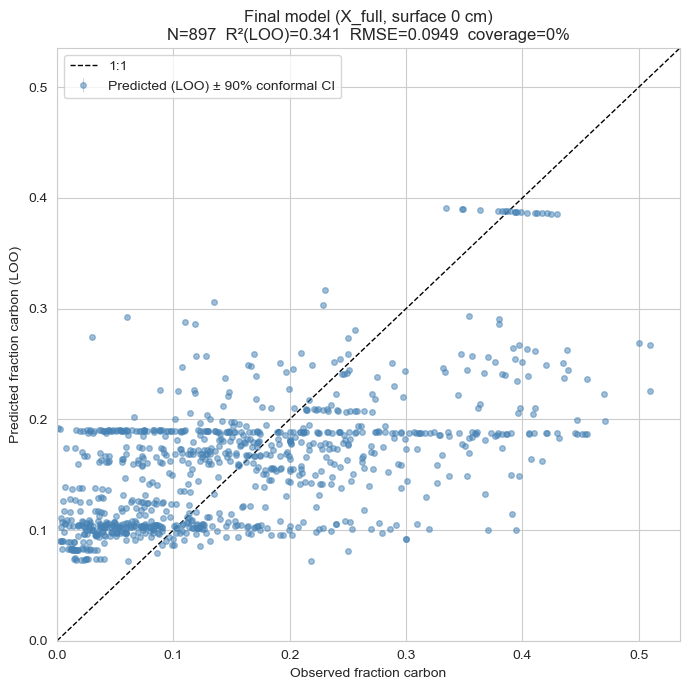


All artifacts saved to C:\Users\kirit\OneDrive\Desktop\CCN-Data-Library-main\CCN-Data-Library-main\scripts\4_capstone\EO\outputs/
Files:
  ablation_study_v2.csv  (0.3 KB)
  ablation_study_v2.png  (87.7 KB)
  cv_comparison_v2.csv  (0.3 KB)
  cv_comparison_v2.png  (36.4 KB)
  depth_comparison_v2.csv  (0.3 KB)
  diagnostics_v2.png  (411.4 KB)
  feature_importances_v2.csv  (0.2 KB)
  feature_names_v2.csv  (0.1 KB)
  final_features_v2_0cm.csv  (0.3 KB)
  final_features_v2_100cm.csv  (0.3 KB)
  final_features_v2_30cm.csv  (0.3 KB)
  final_rf_v2_0cm.pkl  (651.5 KB)
  final_rf_v2_100cm.pkl  (411.9 KB)
  final_rf_v2_30cm.pkl  (455.3 KB)
  final_scaler_v2_0cm.pkl  (1.1 KB)
  final_scaler_v2_100cm.pkl  (1.1 KB)
  final_scaler_v2_30cm.pkl  (1.1 KB)
  headline_scatter_v2.png  (156.1 KB)
  predictions_v2_0cm.csv  (122.6 KB)
  uncertainty_v2.png  (389.4 KB)


In [57]:
# ── Save all artifacts ────────────────────────────────────────────────────────
print("Saving artifacts...")

for depth, res in depth_results.items():
    label = f"{depth}cm"
    joblib.dump(res["model"],  OUT_DIR / f"final_rf_v2_{label}.pkl")
    joblib.dump(res["scaler"], OUT_DIR / f"final_scaler_v2_{label}.pkl")
    pd.DataFrame({"feature": res["feature_names"]}).to_csv(
        OUT_DIR / f"final_features_v2_{label}.csv", index=False
    )

# Predictions with uncertainty (surface depth)
if 0 in depth_results:
    pred_df = pd.DataFrame({
        "study_id": groups,
        "site_id":  sites,
        "observed": y,
        "predicted_loo": y_pred_loo,
        "ci90_lower_conformal": cf_lower,
        "ci90_upper_conformal": cf_upper,
        "ci90_lower_qrf":       qrf_lower,
        "ci90_upper_qrf":       qrf_upper,
    })
    pred_df.to_csv(OUT_DIR / "predictions_v2_0cm.csv", index=False)

# Feature selection results (RFECV) - already cached by cell 31 to
# outputs/selected_features.json (see FEATURE_SELECTION_CACHE).
print(f"Selection cache: {FEATURE_SELECTION_CACHE.name}")

# CV comparison
cv_final.to_csv(OUT_DIR / "cv_comparison_v2.csv", index=False)

# Depth summary
summary_df.to_csv(OUT_DIR / "depth_comparison_v2.csv", index=False)

# Feature metadata (full stack actually used by the final model)
pd.DataFrame({"feature": feat_names_full}).to_csv(
    OUT_DIR / "feature_names_v2.csv", index=False
)

# ── Headline scatter: observed vs predicted with 90% conformal CI ────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.errorbar(
    y, y_pred_loo,
    yerr=[y_pred_loo - cf_lower, cf_upper - y_pred_loo],
    fmt="o", ms=4, lw=0.5, alpha=0.5, ecolor="grey", color="steelblue",
    label=f"Predicted (LOO) ± 90% conformal CI",
)
lim = max(y.max(), y_pred_loo.max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=1, label="1:1")
ax.set_xlabel("Observed fraction carbon")
ax.set_ylabel("Predicted fraction carbon (LOO)")
loo_r2 = r2_score(y, y_pred_loo)
loo_rmse = float(np.sqrt(mean_squared_error(y, y_pred_loo)))
ax.set_title(
    f"Final model (X_full, surface 0 cm)\n"
    f"N={len(y)}  R²(LOO)={loo_r2:.3f}  RMSE={loo_rmse:.4f}  "
    f"coverage={cf_coverage:.0%}"
)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / "headline_scatter_v2.png", dpi=150)
plt.show()

print(f"\nAll artifacts saved to {OUT_DIR.resolve()}/")
print("Files:")
for f in sorted(OUT_DIR.glob("*v2*")):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")
